<a href="https://colab.research.google.com/github/giselegradesa-max/laboratorio-ia/blob/main/meu_primeiro_teste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
mensagem = "Estou aprendendo Google Colab com o Profe!"
print(mensagem)

Estou aprendendo Google Colab com o Profe!


# 📊 Projeto 1: Analisador de Sentimentos para Avaliações de Produtos
**Desenvolvido por:** [Seu Nome]  
**Mentor:** Profe IA  
**Tecnologias:** Python, TextBlob, Pandas, Matplotlib, Google Colab

--- TABELA DE RESULTADOS ---
                                            Feedback Sentimento
0  O produto é excelente, superou todas as minhas...     Neutro
1  A entrega atrasou e o produto veio com defeito...     Neutro
2  O produto é razoável, cumpre o que promete mas...     Neutro
3  Adorei a qualidade e o atendimento foi sensaci...     Neutro
4          Péssimo serviço. Não recomendo a ninguém.     Neutro
5            A embalagem é bonita e chegou no prazo.     Neutro
6        Não gostei do material, achei muito frágil.     Neutro


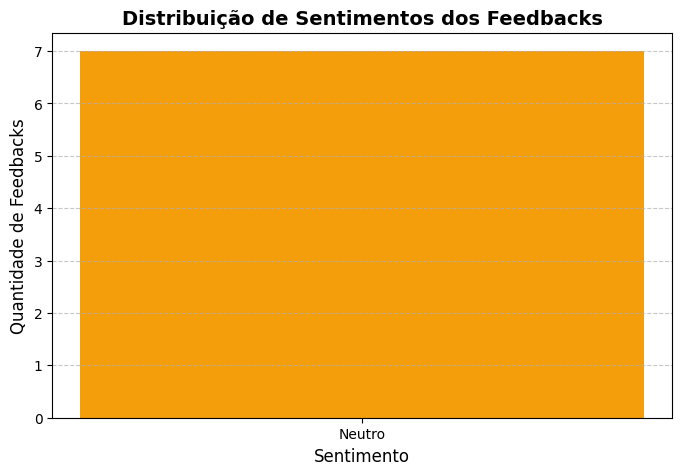

In [6]:
# 1. Instalação da biblioteca de Processamento de Linguagem Natural
!pip install textblob -q

import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

# 2. Base de Dados de Exemplo (Avaliações de Clientes)
avaliacoes = [
    "O produto é excelente, superou todas as minhas expectativas!",
    "A entrega atrasou e o produto veio com defeito. Muito insatisfeita.",
    "O produto é razoável, cumpre o que promete mas nada demais.",
    "Adorei a qualidade e o atendimento foi sensacional!",
    "Péssimo serviço. Não recomendo a ninguém.",
    "A embalagem é bonita e chegou no prazo.",
    "Não gostei do material, achei muito frágil."
]

# 3. Função do Agente Dev para Analisar Sentimento
def analisar_sentimento(texto):
    # Traduzimos para inglês temporariamente para usar o modelo de polaridade nativo do TextBlob
    blob = TextBlob(texto)
    try:
        texto_en = str(blob.translate(from_lang='pt', to='en'))
        polaridade = TextBlob(texto_en).sentiment.polarity
    except:
        polaridade = blob.sentiment.polarity

    if polaridade > 0.1:
        return 'Positivo'
    elif polaridade < -0.1:
        return 'Negativo'
    else:
        return 'Neutro'

# 4. Processando os dados
df = pd.DataFrame({'Feedback': avaliacoes})
df['Sentimento'] = df['Feedback'].apply(analisar_sentimento)

# Exibir tabela formatada
print("--- TABELA DE RESULTADOS ---")
print(df)

# 5. Gerando Visualização dos Resultados
plt.figure(figsize=(8, 5))
contagem = df['Sentimento'].value_counts()
cores = {'Positivo': '#10b981', 'Neutro': '#f59e0b', 'Negativo': '#ef4444'}

plt.bar(contagem.index, contagem.values, color=[cores.get(x, '#3b82f6') for x in contagem.index])
plt.title('Distribuição de Sentimentos dos Feedbacks', fontsize=14, fontweight='bold')
plt.xlabel('Sentimento', fontsize=12)
plt.ylabel('Quantidade de Feedbacks', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()